# IBM HR Employee 


In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('IBM_dataset.csv')


In [4]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [5]:
df.shape

(1470, 35)

In [6]:
df.columns.str.strip()


Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [7]:
df.dtypes         # check data types


Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

In [8]:
df.isnull().sum() # check nulls


Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [9]:
df.duplicated().sum() # check duplicates


np.int64(0)

In [10]:
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)


In [11]:
df['AttritionFlag'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['AttritionFlag']

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: AttritionFlag, Length: 1470, dtype: int64

In [16]:
col_index = df.columns.get_loc('Attrition')


In [17]:
df.insert(col_index + 1, 'AttritionFlag', df.pop('AttritionFlag'))


In [12]:
df['SalaryBand'] = pd.cut(df['MonthlyIncome'],
                    bins=[0, 3000, 6000, 10000, 20000],
                    labels=['Low', 'Mid', 'High', 'Very High'])
df['SalaryBand']


0        Mid
1        Mid
2        Low
3        Low
4        Mid
        ... 
1465     Low
1466    High
1467    High
1468     Mid
1469     Mid
Name: SalaryBand, Length: 1470, dtype: category
Categories (4, str): ['Low' < 'Mid' < 'High' < 'Very High']

In [19]:
col_index = df.columns.get_loc('MonthlyIncome')

In [20]:
df.insert(col_index + 1, 'SalaryBand', df.pop('SalaryBand'))


In [21]:
df

,Age,Attrition,AttritionFlag,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,...,2,80,0,7,3,3,0,0,0,0
3,33,No,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,...,3,80,0,8,3,3,8,7,3,0
4,27,No,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,0,Travel_Frequently,884,Research & Development,23,2,Medical,1,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,0,Travel_Rarely,613,Research & Development,6,1,Medical,1,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,0,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,0,Travel_Frequently,1023,Sales,2,3,Medical,1,...,4,80,0,17,3,2,9,6,0,8


In [22]:
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18',
    'StandardHours', 'DailyRate', 'HourlyRate', 'MonthlyRate'
]
df.drop(columns=cols_to_drop)

,Age,Attrition,AttritionFlag,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,1,Travel_Rarely,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,0,Travel_Frequently,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,1,Travel_Rarely,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,0,Travel_Frequently,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,0,Travel_Rarely,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,0,Travel_Frequently,Research & Development,23,2,Medical,3,Male,...,3,3,1,17,3,3,5,2,0,3
1466,39,No,0,Travel_Rarely,Research & Development,6,1,Medical,4,Male,...,3,1,1,9,5,3,7,7,1,7
1467,27,No,0,Travel_Rarely,Research & Development,4,3,Life Sciences,2,Male,...,4,2,1,6,0,3,6,2,0,3
1468,49,No,0,Travel_Frequently,Sales,2,3,Medical,4,Male,...,3,4,0,17,3,2,9,6,0,8


In [23]:
df.to_csv('Data_Cleaned/ibm_hr_cleaned.csv', index=False)

In [24]:
df_new = pd.read_csv('Data_Cleaned/ibm_hr_cleaned.csv')

In [25]:
df_new

,Age,Attrition,AttritionFlag,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,...,2,80,0,7,3,3,0,0,0,0
3,33,No,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,...,3,80,0,8,3,3,8,7,3,0
4,27,No,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,0,Travel_Frequently,884,Research & Development,23,2,Medical,1,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,0,Travel_Rarely,613,Research & Development,6,1,Medical,1,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,0,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,0,Travel_Frequently,1023,Sales,2,3,Medical,1,...,4,80,0,17,3,2,9,6,0,8


In [26]:
# Q1 — Overall attrition rate
Attrition_rate = df['AttritionFlag'].mean() * 100
print(f"Overall Attrition Rate: {Attrition_rate:.1f}%")


Overall Attrition Rate: 16.1%


In [27]:
# Q2 — Attrition by Department
Dept_attrition = df.groupby('Department')['AttritionFlag'].mean().mul(100).round(1)
print("\nAttrition by Department   (%)")
print(Dept_attrition.sort_values(ascending=False))


Attrition by Department   (%)
Department
Sales                     20.6
Human Resources           19.0
Research & Development    13.8
Name: AttritionFlag, dtype: float64


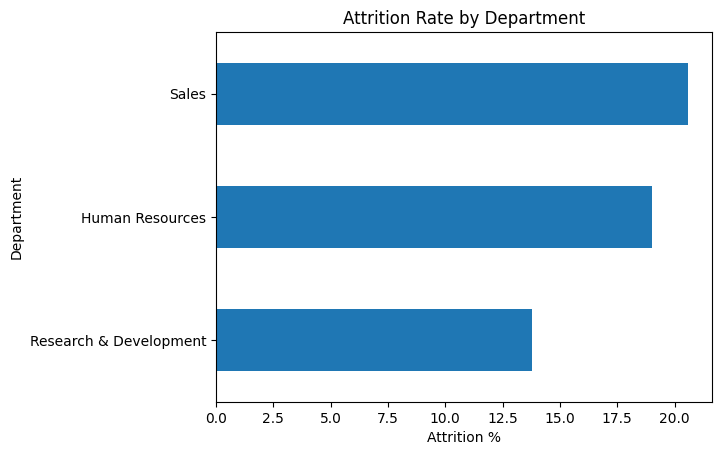

In [28]:
Dept_attrition.sort_values().plot(kind='barh')
plt.title("Attrition Rate by Department")
plt.xlabel("Attrition %")
plt.show()

In [29]:
# Q3 — Attrition by Salary Band
Salary_Attrition = df.groupby('SalaryBand')['AttritionFlag'].mean().mul(100).round(1)
print(Salary_Attrition)

SalaryBand
Low          28.6
Mid          12.7
High         12.0
Very High     8.9
Name: AttritionFlag, dtype: float64


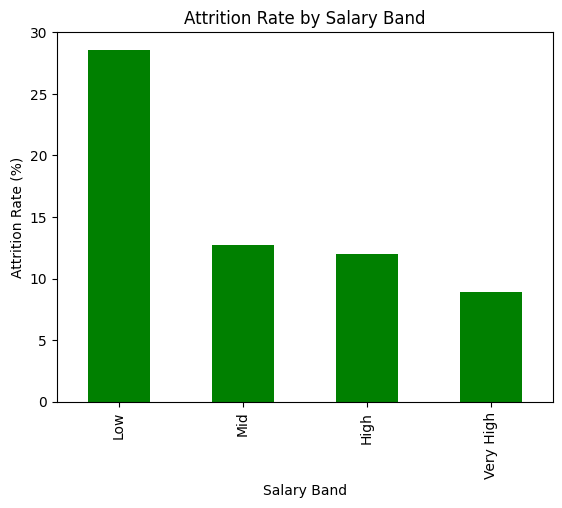

In [30]:
Salary_Attrition.sort_index().plot(kind='bar', color='green')
plt.title("Attrition Rate by Salary Band")
plt.xlabel("Salary Band")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [31]:
# Q4 — Attrition by Years at Company (tenure risk)
Tenure_Attrition = df.groupby('YearsAtCompany')['AttritionFlag'].mean().mul(100).round(1)
print(Tenure_Attrition.head(10))

YearsAtCompany
0    36.4
1    34.5
2    21.3
3    15.6
4    17.3
5    10.7
6    11.8
7    12.2
8    11.2
9     9.8
Name: AttritionFlag, dtype: float64


In [32]:
# Q5 — Attrition by Job Role
Role_Attrition = df.groupby('JobRole')['AttritionFlag'].mean().mul(100).round(1)
print(Role_Attrition.sort_values(ascending=False))

JobRole
Sales Representative         39.8
Laboratory Technician        23.9
Human Resources              23.1
Sales Executive              17.5
Research Scientist           16.1
Healthcare Representative     6.9
Manufacturing Director        6.9
Manager                       4.9
Research Director             2.5
Name: AttritionFlag, dtype: float64


In [33]:
# Q6 — Overtime impact on attrition
Ot_Attrition = df.groupby('OverTime')['AttritionFlag'].mean().mul(100).round(1)
print(Ot_Attrition)

OverTime
No     10.4
Yes    30.5
Name: AttritionFlag, dtype: float64
